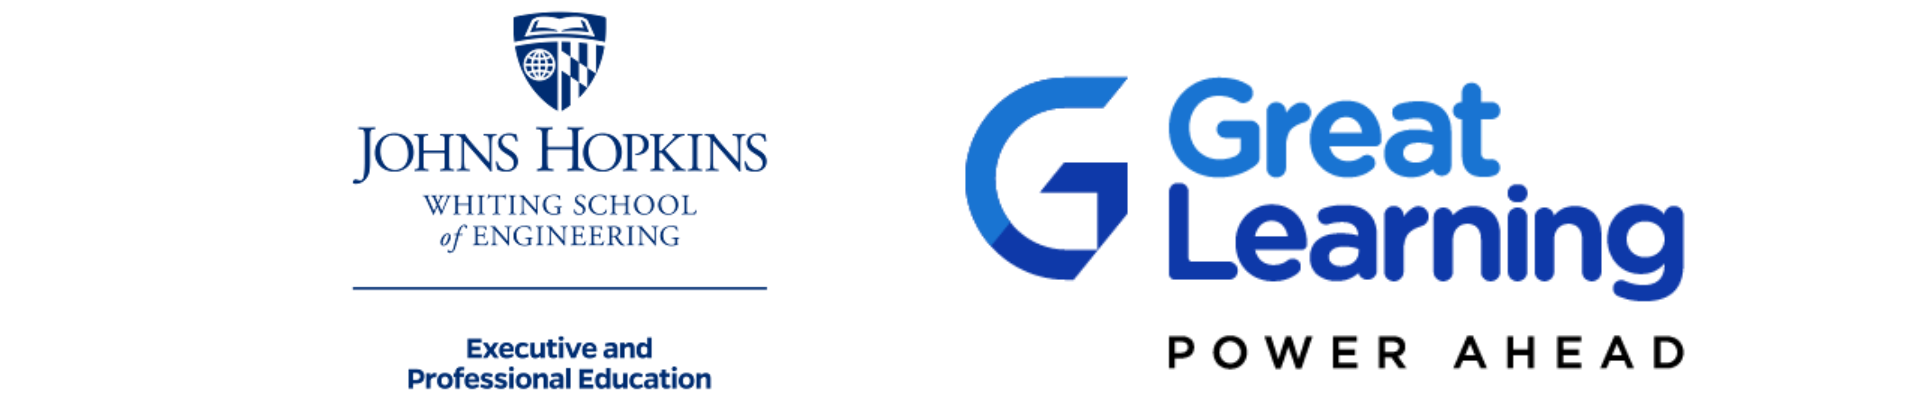

<div style='background: linear-gradient(135deg, #0d2b45 0%, #1f6f78 100%); padding: 32px; border-radius: 14px; color: white;'>
  
  <h1 style='margin: 0; font-size: 2.3em;'><b>🔍 DualLens Analytics — Trustworthy AI Investment Research</b></h1>
  <h2 style='margin: 12px 0 0 0; font-weight: 300;'>Grounded RAG · LLM-as-Judge Evaluation · Self-Improving Prompts (DSPy + GEPA) · Confidence-Routed Decisions</h2>
  <p style='margin: 18px 0 0 0; font-size: 1.05em;'>Build an AI research system that fuses live financial data with company strategy documents — and, unlike a naive chatbot, <b>measures</b> its own answer quality, <b>optimizes</b> its own prompt against a gold dataset, and <b>routes</b> its final recommendation by confidence so no untrusted answer ever reaches a client.</p>
</div>

## 🎯 **Objectives**

By completing this notebook, you will be able to:

✅ **Fuse quantitative + qualitative data sources** — pull live market data with finance and combine it with insights retrieved from unstructured PDF reports.

✅ **Build a metadata-filtered RAG pipeline** — chunk, embed, and store documents in ChromaDB with company tags, so a question about MSFT never gets answered from GOOGL passages.

✅ **Diagnose retrieval separately from generation** — use a gold dataset to measure whether failures come from *fetching the wrong passages* or *answering badly from good passages*.

✅ **Design a 3-metric LLM-as-Judge harness** — score every answer on Groundedness, Context Relevance, and Answer Relevance with machine-readable rubrics, and cross-validate judges against an objective accuracy check.

✅ **Optimize prompts automatically with DSPy + GEPA** — recast the prompt as a typed `dspy.Signature`, drive GEPA with a deterministic gold-set metric, and prove the improvement on **held-out questions the optimizer never saw**.

✅ **Ship decisions with confidence routing** — aggregate evaluation signals into a confidence score and route the final investment ranking: client-ready / flagged / held for human review.

## 📊 **Marking Scheme (Total: 20 Marks)**

<div style='background-color: #fff3e0; padding: 18px; border-radius: 10px; border: 2px solid #ff9800;'>

### 📍 <font color="#c0392b">**Part 1 — Core Pipeline (8 marks)**</font>
<font color="#8e44ad">

- Financial lens — stock history + metrics DataFrame + visualizations — **2 marks**
- Narrative lens — PDF ingestion, chunking with company metadata, ChromaDB vector store — **2 marks**
- Grounded RAG function + 5-query typed test suite (incl. out-of-scope trap) — **3 marks**
- Retrieval diagnostics — gold-set hit-rate with vs. without the company filter — **1 mark**
</font>

### 📍 <font color="#c0392b">**Part 2 — Evaluation (5 marks)**</font>
<font color="#8e44ad">

- Three LLM-as-Judge rubrics (Groundedness, Context Relevance, Answer Relevance) + batch evaluation loop + pass/fail table — **3 marks**
- Objective gold-set accuracy check (`expected_substring`) + per-company breakdown + judge cross-validation — **2 marks**
</font>

### 📍 <font color="#c0392b">**Part 3 — Optimization & Decision Layer (5 marks)**</font>
<font color="#8e44ad">

- DSPy `Signature` + retrieval-aware `Module` + deterministic metric with feedback — **2 marks**
- GEPA compilation + evolved-prompt inspection + before/after comparison on the held-out test split — **2 marks**
- Fused ranking (financial + retrieved insights) + confidence score + routing verdict — **1 mark**
</font>

### 📍 <font color="#c0392b">**Part 4 — Summary & Future Scope (2 marks)**</font>
<font color="#8e44ad">

- Observations & learnings — **1 mark**
- Future scope (what would you build next?) — **1 mark**
</font>
</div>


## 📑 **Table of Contents**

1. [Introduction & Business Problem](#section1)
2. [System Architecture Overview](#section2)
3. [Environment Setup](#section3)
4. [Step 1 — Financial Lens: Market Data & Visualization](#section4)
5. [Step 2 — Narrative Lens: Document Ingestion & Vectorization](#section5)
6. [Step 3 — Grounded Q&A: The RAG Pipeline](#section6)
7. [Step 4 — Quality Control: LLM-as-Judge Evaluation](#section7)
8. [Step 5 — Self-Improvement: Prompt Optimization with DSPy + GEPA](#section8)
9. [Step 6 — Decision Layer: Fused Ranking + Confidence Routing](#section9)
10. [Step 7 — Summary & Future Scope](#section10)

## 📖 **Glossary**

Skim this once before reading the rest — the notebook uses these terms throughout.

<div style='background-color: #f0f4ff; padding: 16px; border-radius: 8px; border-left: 4px solid #1f6f78;'>

### 💼 Domain terms

| Term | Meaning |
|---|---|
| **Market Cap** | Total market value of a company's outstanding shares. |
| **P/E Ratio** | Price-to-Earnings — how much investors pay per dollar of earnings. High P/E = priced for growth. |
| **Dividend Yield** | Annual dividend income as a percentage of the stock price. |
| **Beta** | A stock's volatility relative to the overall market (1.0 = moves with the market). |
| **Grounding** | Forcing every claim in an AI answer to trace back to a source document the firm has verified. |
| **Hallucination** | A confident AI claim that does **not** exist in any source document — the failure that almost shipped to a DualLens client. |
| **Gold dataset** | `golden_retrieval.csv` — 20 questions with verified correct answers (`expected_substring`) drawn from the source PDFs. Our objective measuring stick. |
| **Confidence routing** | Sending outputs down different paths based on measured quality: client-ready / flagged / held for human review. |

</div>

<div style='background-color: #f4f0ff; padding: 16px; border-radius: 8px; border-left: 4px solid #6a3ec9; margin-top: 10px;'>

### 🧠 Technical terms

| Term | Meaning |
|---|---|
| **RAG** | Retrieval-Augmented Generation — fetch the most relevant document passages, then have the LLM answer **only** from them. |
| **Chunk** | A small, overlapping slice of a document (~512 tokens here) — the unit that gets embedded and retrieved. |
| **Embedding** | A numerical "fingerprint of meaning" for a chunk of text. Similar meanings → nearby vectors. |
| **Vector store** | A database (ChromaDB here) that finds chunks whose embeddings are most similar to a question's embedding. |
| **Metadata filter** | Restricting retrieval to chunks tagged with a specific company — our fix for cross-company contamination. |
| **LLM-as-Judge** | Using an LLM with a scoring rubric to grade another LLM's output (1–5 here, with a machine-readable `Score: N` line). |
| **Groundedness** | Judge metric: are the answer's claims actually supported by the retrieved context? |
| **Context Relevance** | Judge metric: did the **retriever** fetch passages that can answer the question? (Evaluates retrieval, not generation.) |
| **Answer Relevance** | Judge metric: does the answer actually address what was asked? |
| **DSPy Signature** | A typed prompt contract — the docstring *is* the prompt, and inputs/outputs are declared fields. |
| **GEPA** | A reflection-based prompt optimizer: score candidates → read failure feedback → rewrite the prompt → keep the winners → repeat. |
| **Reflection LM** | The model inside GEPA that reads the metric's feedback and proposes the next prompt rewrite. |
| **Train/test split** | Letting the optimizer learn from one slice of the gold set (12 questions) and proving generalization on a hidden slice (8 questions). |

</div>

<a name='section1'></a>
## 1️⃣ **Introduction & Business Problem**

### 💼 **The Challenge**

**DualLens Analytics** is a boutique investment research firm. Its analysts answer one deceptively simple question for clients: *"Which technology companies are worth investing in right now?"*

Answering it well requires two lenses at once:

- **The numbers lens** — stock trends, market capitalization, revenue, valuation ratios. Structured, abundant, easy to chart.
- **The narrative lens** — what a company is actually *building* for the future, especially its AI initiatives. This lives in long strategy reports: unstructured, dense, slow to read.

Until recently the narrative lens was manual: 10–12 analyst-hours per company, per refresh, across a five-company universe (**GOOGL, MSFT, IBM, NVDA, AMZN**).

Six months ago the firm piloted an AI assistant — paste the documents into an LLM, ask questions, get answers. It was fast, and it became a liability. In a client-facing report the assistant confidently described an NVDA project timeline **that didn't exist in any source document**. A senior analyst caught it two hours before the report shipped. An internal audit found the same pattern repeatedly:

- Answers that mixed up **which company** a project belonged to
- **Fabricated specifics** (dates, dollar figures) not present in any document
- **No way to tell** a reliable answer from an unreliable one — every answer *sounded* equally confident

The firm's conclusion: the problem was never getting an AI to produce answers. The problem is producing answers you can **trust, measure, and improve**.

### 💡 **The Solution**

**DualLens 2.0** — a RAG system with a built-in quality-control layer and a self-improving prompt:

1. **Grounds every answer in source documents** — retrieval + a strict "answer only from context, else say *I don't know*" contract.
2. **Measures answer quality automatically** — an LLM judge scores every answer on three dimensions, cross-checked against an objective gold dataset.
3. **Improves its own prompt** — GEPA reads failure feedback and rewrites the prompt, with the improvement *proven* on questions the optimizer never saw.
4. **Routes outputs by confidence** — the final investment ranking carries a confidence score; low-confidence outputs are held for human review, never silently trusted.

### 💸 **Cost of Inaction**

One shipped hallucination in a client report risks regulatory scrutiny and the firm's reputation. Reverting to manual reading means the research desk simply cannot scale beyond five companies. The system below is what turns analysts from *document readers* into *reviewers of flagged outputs*.

<a name='section2'></a>
## 2️⃣ **System Architecture Overview**

### 🏗️ **The Evaluation-Driven Pipeline**

Unlike the failed pilot — which generated answers and stopped — every generation stage here is paired with a measurement stage, and the measurements feed back into improving the system.

```
 ┌─────────────────────┐        ┌──────────────────────────┐
 │  STEP 1             │        │  STEP 2                  │
 │  Financial Lens     │        │  Narrative Lens          │
 │  yfinance → charts  │        │  PDFs → chunks → Chroma  │
 │  + metrics table    │        │  (+ company metadata)    │
 └─────────┬───────────┘        └────────────┬─────────────┘
           │                                 │
           │                    ┌────────────▼─────────────┐
           │                    │  STEP 3                  │
           │                    │  Grounded RAG Q&A        │
           │                    │  filtered retrieval +    │
           │                    │  strict-context prompt   │
           │                    └────────────┬─────────────┘
           │                                 │
           │                    ┌────────────▼─────────────┐
           │                    │  STEP 4                  │
           │                    │  Judge Harness (3 LLM    │
           │                    │  metrics) + Gold-set     │
           │                    │  objective accuracy      │
           │                    └────────────┬─────────────┘
           │                                 │ failure feedback
           │                    ┌────────────▼─────────────┐
           │                    │  STEP 5                  │
           │                    │  DSPy + GEPA prompt      │
           │                    │  optimization (train 12, │
           │                    │  prove on held-out 8)    │
           │                    └────────────┬─────────────┘
           │                                 │ optimized RAG
           └────────────────┬────────────────┘
                            │
               ┌────────────▼─────────────┐
               │  STEP 6                  │
               │  Fused Ranking +         │
               │  Confidence Score        │
               │  ✅ client-ready          │
               │  ⚠️ flagged               │
               │  🛑 held for human review │
               └──────────────────────────┘
```

### 🤖 **Cast of Characters (all `gpt-4o-mini`)**

| Role | Job | Settings |
|---|---|---|
| **Answerer LLM** | Generates grounded answers from retrieved context | `temperature=0` (deterministic) |
| **Judge LLM** | Scores answers on the three 1–5 rubrics | `temperature=0`, separate object from the answerer |
| **Task LM (DSPy)** | Runs candidate prompts during GEPA compilation | `temperature=0.1` |
| **Reflection LM (GEPA)** | Reads failure feedback, proposes prompt rewrites | `temperature=1.0` — creative variation helps reflection |

> 💰 **Single-model cost note.** A production setup would typically use a *stronger* model as judge/reflector. We run everything on `gpt-4o-mini` to keep costs minimal — and the design choice that makes this viable is the **deterministic gold-set metric** in Step 5: the optimization loop is scored by free Python (substring checks), not by noisy small-model judge calls. This trade-off is itself a real-world lesson.

### 🔁 **Logical Flow**

1. Build both lenses (Steps 1–2) → 2. Answer questions with grounded RAG (Step 3) → 3. Measure quality with judges + the gold dataset (Step 4) → 4. Let GEPA optimize the prompt against the gold-set metric and prove it generalizes (Step 5) → 5. Fuse both lenses into a ranked recommendation, score its confidence, and route it (Step 6).

<a name='section3'></a>
## 3️⃣ **Environment Setup**

### 3.1 · Install dependencies

In [ ]:
# Installing the Libraries
!pip install -q --upgrade \
    "langchain>=1.0,<2.0" \
    "langchain-core>=1.0,<2.0" \
    "langchain-community>=0.4.2" \
    "langchain-openai>=0.3.0" \
    "langchain-chroma>=0.2.0" \
    "langchain-text-splitters>=0.3.0" \
    "chromadb>=0.5.0" \
    "pypdf>=4.0.0" \
    "openai>=1.40.0" \
    "tiktoken>=0.7.0" \
    "dspy==3.2.1" \
    "scikit-learn>=1.4" \
    "yfinance>=0.2.40"
print("### Library Installation - Done")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.0/331.0 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.5/146.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

**Note:** Messages above may appear as errors, but they can be safely ignored. They are caused by minor dependency mismatches in optional packages and do not affect the functionality of this notebook.

### After installation, please **restart the runtime** and **do not re-run the above cell**. Continue execution from the next cell below.

### 3.2 · Load your OpenAI API key

- The `config.json` file should contain the **API_KEY** and **API BASE URL** provided for your account.
- Refer to the **OpenAI Access Token documentation** for how to generate and manage your API keys.
- The `config.json` should look like this:

```
{
    "API_KEY": "your_openai_api_key_here",
    "OPENAI_API_BASE": "https://your_openai_api_base/v1"
}
```

In [ ]:
# Load the `config.json` file and extract API key + base URL
import json
import os

file_name = 'config.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    os.environ['OPENAI_API_KEY'] = config.get("API_KEY")           # Loading the API Key
    os.environ["OPENAI_BASE_URL"] = config.get("OPENAI_API_BASE")  # Loading the API Base URL

print("API credentials loaded into the environment.")

API credentials loaded into the environment.


In [ ]:
# Quick connectivity check — confirms the key + base URL actually reach a working endpoint
from openai import OpenAI

_client = OpenAI()
_ping = _client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "Reply with exactly: OK"}],
    max_tokens=5,
)
print("Connectivity check:", _ping.choices[0].message.content)

Connectivity check: OK


### 3.3 · Configuration & shared imports

One place for every knob the notebook uses. If you change a model or a retrieval depth, change it here.

In [ ]:
# Core imports used across the notebook.
import warnings
warnings.filterwarnings('ignore')

import re
import time
import zipfile
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

pd.set_option("display.max_colwidth", 120)

In [ ]:
# ---- Models ----------------------------------------------------------
# Single-model setup: gpt-4o-mini everywhere (see the cost note in Section 2).
MODEL_NAME      = "gpt-4o-mini"
EMBEDDING_MODEL = "text-embedding-3-small"

# ---- Companies under coverage ----------------------------------------
COMPANIES = ["GOOGL", "MSFT", "IBM", "NVDA", "AMZN"]

# ---- Retrieval & chunking knobs --------------------------------------
CHUNK_SIZE    = 512   # tokens per chunk (token-based splitting matches what models actually count)
CHUNK_OVERLAP = 64    # tokens shared between neighbouring chunks, so facts at boundaries aren't cut in half
TOP_K         = 4     # chunks retrieved per question

# ---- Evaluation & routing policy --------------------------------------
PASS_THRESHOLD       = 4      # a judge metric "passes" at >= 4 out of 5
CONF_CLIENT_READY    = 80     # confidence >= 80  -> ✅ client-ready
CONF_FLAGGED         = 60     # 60 <= conf < 80   -> ⚠️ flagged for awareness
                              # conf < 60         -> 🛑 held for human review

# ---- LLM objects -------------------------------------------------------
# Answerer — generates the RAG response. temperature=0 keeps answers stable
# and grounded; max_tokens caps response length.
llm = ChatOpenAI(model=MODEL_NAME, temperature=0, max_tokens=1024)

# Judge — a SEPARATE object so the evaluation role is explicit. In production
# this would be a stronger model; here it shares gpt-4o-mini for cost, which
# is exactly why Step 4 cross-validates the judges against the gold dataset.
judge_llm = ChatOpenAI(model=MODEL_NAME, temperature=0, max_tokens=600)

print(f"Configured: answerer={MODEL_NAME}, judge={MODEL_NAME}, embeddings={EMBEDDING_MODEL}")

Configured: answerer=gpt-4o-mini, judge=gpt-4o-mini, embeddings=text-embedding-3-small


<a name='section4'></a>
## 4️⃣ **Step 1 — Financial Lens: Market Data & Visualization**

The quantitative half of DualLens. We pull three years of price history plus five headline financial metrics for the coverage universe, and visualize them. These numbers feed the fused ranking in Step 6.

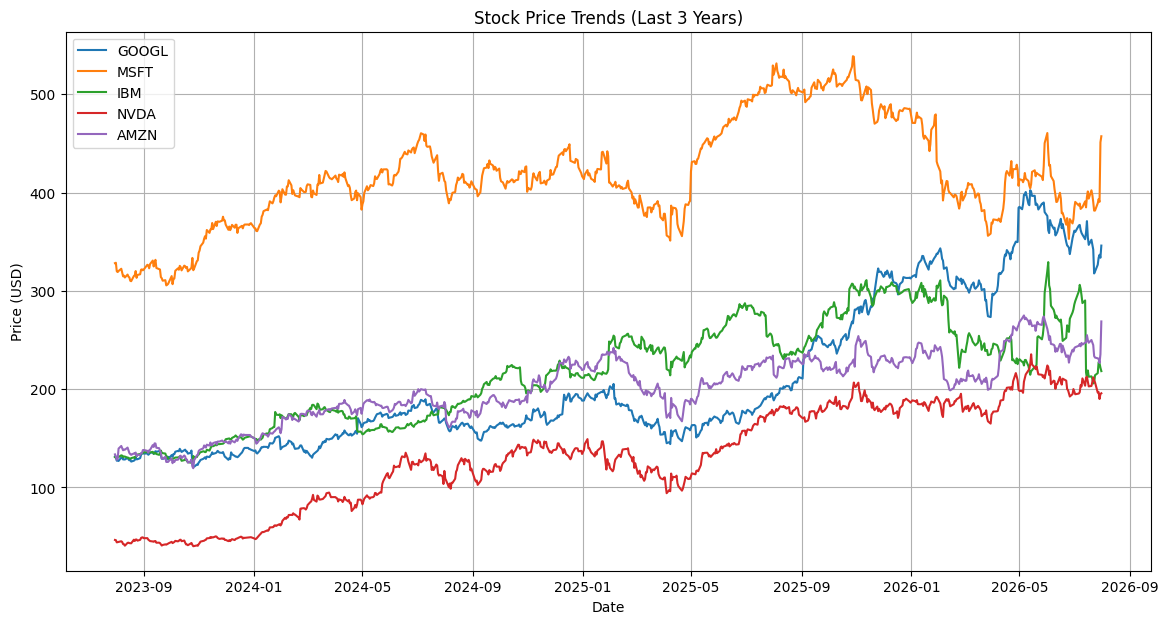

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Three-year price trend chart
# ═══════════════════════════════════════════════════════════════════════════
# One shared figure: the 3-year closing-price trend of all five companies.
# Replace each `...` below.
# ───────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7))

for symbol in COMPANIES:
    ticker = yf.Ticker(symbol)
    data =  ticker.history(period="3y")
    plt.plot(data.index, data["Close"], label=symbol)
plt.title("Stock Price Trends (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

#### 💹 Financial Metrics

1. **Market Cap** — total market value of a company's outstanding shares.
2. **P/E Ratio** — how much investors are willing to pay per dollar of earnings.
3. **Dividend Yield** — annual dividend income as a percentage of the stock price.
4. **Beta** — a stock's volatility relative to the overall market.
5. **Total Revenue** — total income generated from business operations.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Financial metrics DataFrame
# ═══════════════════════════════════════════════════════════════════════════
# Fetch the five headline metrics per company into `fin_df`.
# "Market Cap" is done for you as the worked example — complete the other four.
# 💡 Hint: explore ticker.info's keys; use .get(key, 0) since some companies
#          don't report every field.
# ───────────────────────────────────────────────────────────────────────────
metrics_list = {}

for symbol in COMPANIES:
    ticker = yf.Ticker(symbol)
    info = ticker.info
    metrics_list[symbol] = {
        "Market Cap":     info.get("marketCap", 0),
        "P/E Ratio":      info.get("trailingPE", 0),
        "Dividend Yield": info.get("dividendYield", 0),
        "Beta":           info.get("beta", 0),
        "Total Revenue":  info.get("totalRevenue",0),
    }

# Convert to a DataFrame (companies as the index) and make it readable:
fin_df = pd.DataFrame(metrics_list).T
fin_df["Market Cap"]    = fin_df["Market Cap"] / 1e9
fin_df["Total Revenue"] = fin_df["Total Revenue"]/1e9
fin_df = fin_df.round(2)

fin_df

,Market Cap,P/E Ratio,Dividend Yield,Beta,Total Revenue
GOOGL,4229.36,17.36,0.26,1.25,445.87
MSFT,3397.63,25.49,0.81,1.13,331.84
IBM,205.72,19.39,3.05,0.68,69.09
NVDA,4740.53,29.17,0.51,2.21,253.49
AMZN,2888.07,21.60,0.00,0.00,775.68


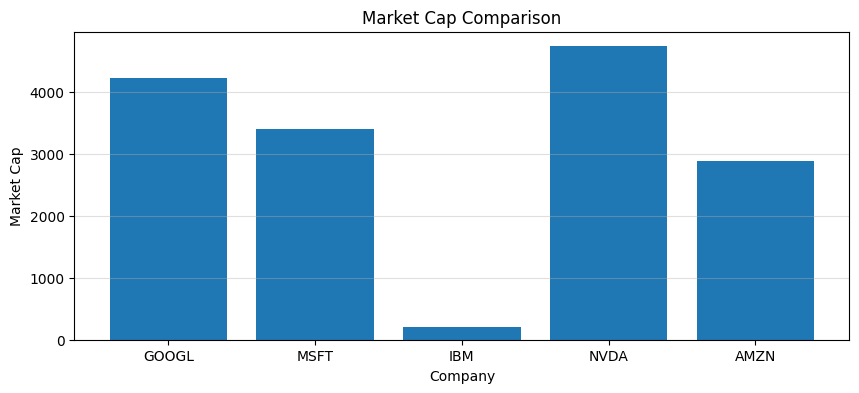

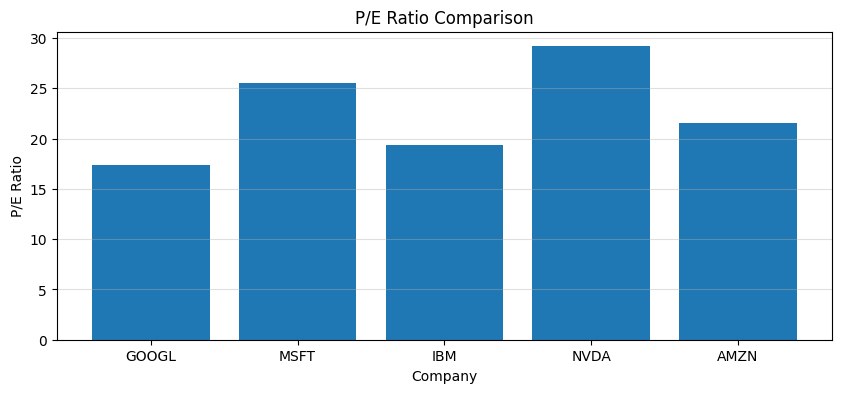

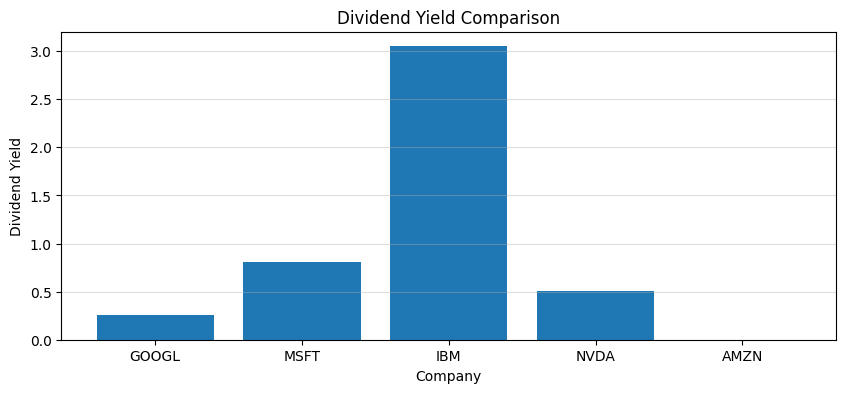

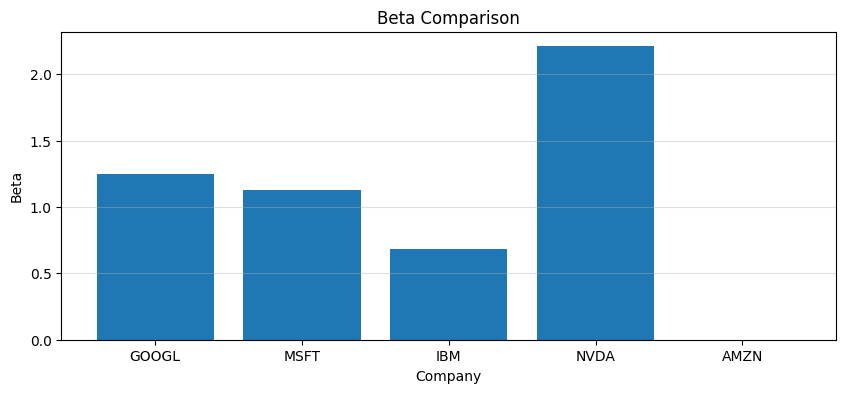

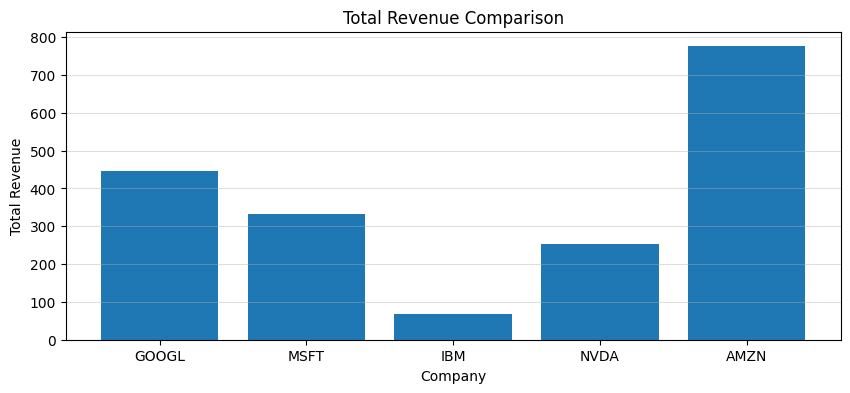

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Per-metric comparison charts
# ═══════════════════════════════════════════════════════════════════════════
# One bar chart per metric, comparing all five companies.
# ───────────────────────────────────────────────────────────────────────────
metrics_to_plot = ["Market Cap", "P/E Ratio", "Dividend Yield", "Beta", "Total Revenue"]

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 4))
    plt.bar(fin_df.index, fin_df[metric])
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.xlabel("Company")
    plt.grid(axis='y', alpha=0.4)
    plt.show()

### 🔎 Your Observations — The Financial Lens

*Write 2–4 bullets. Consider:*
- Priced for growth: NVIDIA (NVDA) — highest P/E ratio (29.17), implying a richer valuation and stronger expected future earnings growth; beta of 2.21 indicates higher volatility.
- Defensive/dividend profile: IBM — highest dividend yield (3.05%) and low beta (0.68), suggesting steadier returns and greater income appeal.
- These metrics cannot show whether growth prospects or AI strategy are sustainable.
- That evidence would come from earnings calls, annual reports, management guidance, product roadmaps, and risk disclosures.
- *Note: yfinance returns live data, so describe the pattern you actually see in your run.*

<a name='section5'></a>
## 5️⃣ **Step 2 — Narrative Lens: Document Ingestion & Vectorization**

The qualitative half. Five PDF reports (one per company) describing each organization's AI initiatives — summaries, objectives, timelines, investments, risks.

**The one design decision that matters most in this section:** every chunk gets a `company` **metadata tag** derived from its source filename. In the failed pilot, a question about MSFT could be answered from GOOGL passages because all documents lived in one undifferentiated pool. The tag is what lets us *filter* retrieval per company in Step 3 — and *measure* how much that filter helps.

In [ ]:
# 📂 Unzip the AI-initiative documents into the working directory.
ZIP_PATH    = "/content/Project_Datafiles.zip"
EXTRACT_DIR = "/content/"
PDF_DIR     = "/content/Companies-AI-Initiatives"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

pdf_files = sorted(f for f in os.listdir(PDF_DIR) if f.endswith(".pdf"))
print("Documents found:", pdf_files)

Documents found: ['AMZN.pdf', 'GOOGL.pdf', 'IBM.pdf', 'MSFT.pdf', 'NVDA.pdf']


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Load PDFs and tag every page with its company
# ═══════════════════════════════════════════════════════════════════════════
# This tag is what makes company-filtered retrieval possible in Step 3 — the
# fix for the pilot's company-mix-up failures. (It's also why we load each
# file individually instead of using PyPDFDirectoryLoader.)
# ───────────────────────────────────────────────────────────────────────────
documents = []

for fname in pdf_files:
    ticker = fname.replace(".pdf", "")
    loader = PyPDFLoader(os.path.join(PDF_DIR, fname))
    pages  = loader.load()
    for page in pages:
        page.metadata["company"] = ticker
    documents.extend(pages)

print(f"Loaded {len(documents)} pages across {len(pdf_files)} companies.")

Loaded 44 pages across 5 companies.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Token-based chunking
# ═══════════════════════════════════════════════════════════════════════════
# Split the tagged pages into overlapping, token-sized chunks. Token-based
# splitting aligns chunk sizes with what the models actually count, and
# splitting Documents (not raw text) carries your company tag onto every chunk.
# 💡 Hint: the splitter has a class method for tiktoken-based sizing
#          ('cl100k_base'), and a method that splits Document objects while
#          preserving their metadata.
# ───────────────────────────────────────────────────────────────────────────
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
)

chunks = text_splitter.split_documents(documents)
print(f"Total chunks: {len(chunks)}")

Total chunks: 108


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Sanity-check the chunks
# ═══════════════════════════════════════════════════════════════════════════
# 💡 Hint: collections.Counter over each chunk's company metadata is a one-liner.
# ───────────────────────────────────────────────────────────────────────────
chunk_counts = Counter(chunk.metadata["company"] for chunk in chunks)
print("Chunks per company:", dict(chunk_counts))
print()
print("--- Sample chunk (first 400 chars) ---")
print(chunks[0].page_content[:400])
print(chunks[0].metadata)

Chunks per company: {'AMZN': 25, 'GOOGL': 17, 'IBM': 22, 'MSFT': 19, 'NVDA': 25}

--- Sample chunk (first 400 chars) ---
Amazon  is  a  global  technology  and  e-commerce  giant  that  uses  AI  to  enhance  almost  every  part  
of
 
its
 
business.
 
In
 
retail,
 
AI
 
powers
 
product
 
recommendations,
 
dynamic
 
pricing,
 
fraud
 
detection,
 
and
 
supply
 
chain
 
optimization,
 
making
 
shopping
 
faster
 
and
 
more
 
personalized.
 
Amazon
 
Web
 
Services
 
(AWS)
 
offers
 
AI
 
and
 
machine
 
learni
{'producer': 'Skia/PDF m142 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'AI Initiatives', 'source': '/content/Companies-AI-Initiatives/AMZN.pdf', 'total_pages': 9, 'page': 0, 'page_label': '1', 'company': 'AMZN'}


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Embed and store in ChromaDB
# ═══════════════════════════════════════════════════════════════════════════
embedding_model = OpenAIEmbeddings(model=EMBEDDING_MODEL)

vectorstore = Chroma.from_documents(
  chunks,
     embedding_model,
    collection_name="ai_initiatives",
)

print(f"Vector store ready with {vectorstore._collection.count()} embedded chunks.")

Vector store ready with 108 embedded chunks.


### 🔎 Your Observations — Ingestion & Vectorization

*Write 2–3 bullets. Consider:*
- Chunk counts are reasonably balanced, not equal: AMZN 25, GOOGL 17, IBM 22, MSFT 19, and NVDA 25.
- Each chunk retains a company metadata tag, enabling filtered retrieval and reducing the risk that similar AI terminology retrieves content from the wrong company.
- CHUNK_SIZE=512 balances context with retrieval precision, while CHUNK_OVERLAP=64 preserves continuity across chunk boundaries without excessive duplication. Token-based chunking also reduces the risk of very uneven chunk sizes distorting retrieval.

<a name='section6'></a>
## 6️⃣ **Step 3 — Grounded Q&A: The RAG Pipeline**

### 6.1 · Prompt design

The grounding contract lives in the system prompt: the model may use **only** the supplied context (marked `###Context`), must answer the question (marked `###Question`), and must reply exactly **"I don't know."** when the context lacks the answer. This is the guardrail the failed pilot never had — it converts "confident fabrication" into an honest, detectable miss.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Write the v1.0 grounding system prompt
# ═══════════════════════════════════════════════════════════════════════════
# Write the rules INSIDE the triple quotes. The prompt must instruct the model to:
#   • Use ONLY the information in the supplied context
#   • Respond EXACTLY with: "I don't know." when the context lacks the answer
#   • Never reference the context's structure (no "based on the context...")
#
# ⚠️ Keep it MINIMAL — resist adding extra instructions. This is deliberately
#    your v1.0: Step 4 will measure its weaknesses and Step 5 will let GEPA
#    evolve it. Hand-tuning it now destroys the experiment.
# ───────────────────────────────────────────────────────────────────────────
qna_system_message = """
You are an assistant that answers questions using only the information provided in the context below.
If the context does not contain the information needed to answer the question, respond with exactly: "I don't know."
Do not reference the context, its structure, or that you were given a context — just answer naturally.
"""

In [ ]:
# User message template — slots the retrieved context and the user question into a single turn
qna_user_message_template = """
###Context
{context}

###Question
{question}
"""

### 6.2 · Company-filtered retrieval

`retrieve()` is the single retrieval doorway for the whole notebook. Pass a `company` ticker and Chroma restricts the similarity search to that company's chunks; pass `None` (for cross-company questions) and it searches the full pool.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Build the retrieval helper
# ═══════════════════════════════════════════════════════════════════════════
# Every retrieval in this notebook goes through retrieve().
# 💡 Hint: vectorstore.similarity_search() accepts a `filter` argument that
#          takes a metadata dictionary.
# ───────────────────────────────────────────────────────────────────────────
def retrieve(question: str, company: str | None = None, k: int = TOP_K):
    """Return the top-k most similar chunks, optionally restricted to one company.

    Args:
        question: Natural-language question to embed and search with.
        company:  Ticker like "MSFT" to filter on, or None for the full pool.
        k:        Number of chunks to return.
    """
    search_filter = {"company": company} if company else None
    return vectorstore.similarity_search(question, k=k, filter=search_filter)  #


def format_context(docs) -> str:
    """Join retrieved chunks into a single context string."""
    return "\n\n".join(doc.page_content for doc in docs)

In [ ]:
# 🧪 Demonstrate retrieval end-to-end before wiring the LLM in:
# ask an MSFT question, confirm every returned chunk is tagged MSFT.
demo_question = "What is Microsoft's flagship AI assistant product?"
demo_chunks = retrieve(demo_question, company="MSFT")

print(f"Retrieved {len(demo_chunks)} chunks. Company tags:",
      [c.metadata["company"] for c in demo_chunks])
print()
print("--- First chunk (first 400 chars) ---")
print(demo_chunks[0].page_content[:400])

Retrieved 4 chunks. Company tags: ['MSFT', 'MSFT', 'MSFT', 'MSFT']

--- First chunk (first 400 chars) ---
Microsoft,  founded  in  1975,  is  a  global  technology  leader  specializing  in  software,  cloud  
computing,
 
AI,
 
and
 
enterprise
 
solutions.
 
The
 
company
 
has
 
aggressively
 
expanded
 
its
 
AI
 
capabilities
 
through
 
initiatives
 
such
 
as
 
Azure
 
AI,
 
OpenAI
 
partnership
 
integrations,
 
and
 
proprietary
 
models
 
like
 
Copilot,
 
which
 
enhance
 
productivity
 
in


### 6.3 · The RAG function

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — The grounded RAG function: retrieve -> assemble -> answer
# ═══════════════════════════════════════════════════════════════════════════
qna_prompt = ChatPromptTemplate.from_messages([
    ("system", qna_system_message),
    ("user", qna_user_message_template),
])                                              # provided

def rag_answer(question: str, company: str | None = None) -> str:
    """Answer a question using retrieval-augmented generation.

    Args:
        question: The user's natural-language question.
        company:  Optional ticker to restrict retrieval to one company's documents.
    Returns:
        The model's answer, grounded in the retrieved context.
    """
    relevant_chunks = retrieve(question, company=company)
    context = format_context(relevant_chunks)

    messages = qna_prompt.format_messages(context=context, question=question)
    response = llm.invoke(messages)
    return response.content

### 6.4 · Typed test suite

Five queries, each probing a different capability. (These are smoke tests for *behaviour*; the rigorous *measurement* happens in Step 4.)

### Example 1: Factual lookup — a single specific fact from one company's document.

In [ ]:
# Example 1: factual lookup (single fact, single company)
print(rag_answer("What is Microsoft's flagship AI assistant product?", company="MSFT"))

Microsoft 365 Copilot is Microsoft's flagship AI assistant product.


### Example 2: Listing question — can retrieval surface multiple related facts in one answer?

In [ ]:
# Example 2: listing / multi-fact recall
print(rag_answer("What are the main AI initiatives NVIDIA is working on?", company="NVDA"))

NVIDIA is working on several main AI initiatives, including deep learning, generative AI, digital twins, and industrial automation.


### Example 3: Cross-company comparison — retrieval over the **full pool** (company=None), since the question spans two companies.

In [ ]:
# Example 3: cross-company comparison — no filter, the question itself names both companies
print(rag_answer("How does Google's AI focus differ from Microsoft's AI focus?", company=None))

Google's AI focus emphasizes advanced multimodal AI to improve user engagement, productivity, and search relevance, along with solving technical challenges in areas like retrieval-augmented generation and real-time reasoning. In contrast, Microsoft's AI focus is on enhancing productivity in its Microsoft 365 apps through integrations like Copilot and Azure AI, aiming to streamline workflows and improve decision-making across consumer and business products.


### Example 4: Multi-hop synthesis — connecting facts across chunks of the same document.

In [ ]:
# Example 4: multi-hop synthesis — links Amazon's customer-facing platform to its in-house foundation model
print(rag_answer("What is Amazon's foundation-model platform, and what foundation model has Amazon developed in-house?", company="AMZN"))

Amazon's foundation-model platform is called Amazon Bedrock. The in-house foundation model that Amazon has developed is named Olympus.


### Example 5: Out-of-scope trap — validates the **"I don't know"** guardrail. The documents describe AI initiatives, not quarterly financials, so the only correct answer is an honest miss.

In [ ]:
# Example 5: out-of-scope — tests the "I don't know" guardrail
print(rag_answer("What was IBM's exact revenue in the third quarter of 2025?", company="IBM"))

I don't know.


### 6.5 · Retrieval diagnostics with the gold dataset

`golden_retrieval.csv` contains **20 questions** (4 per company), each with:

| Column | Meaning |
|---|---|
| `question` | A question answerable from exactly one company's document |
| `ticker_hint` | Which company's document holds the answer |
| `expected_substring` | A short, verified token (e.g., *Copilot*, *Granite*, *Bedrock*) that a correct answer **must** contain |

Here we use it to answer a question the judges in Step 4 *cannot* answer on their own: **when the system fails, is it the retriever's fault or the generator's fault?** We check whether the expected token appears in the *retrieved chunks* (before any LLM is involved) — with the company filter on vs. off.

In [ ]:
# 📂 Load the gold dataset
gold = pd.read_csv("/content/golden_retrieval.csv")
print(f"{len(gold)} gold questions, balanced across companies:")
print(gold["ticker_hint"].value_counts().to_dict())
gold.head()

20 gold questions, balanced across companies:
{'MSFT': 4, 'GOOGL': 4, 'IBM': 4, 'NVDA': 4, 'AMZN': 4}


,question,ticker_hint,expected_substring
0,What is Microsoft's flagship AI assistant product brand?,MSFT,Copilot
1,Which Microsoft cloud platform hosts AI services?,MSFT,Azure
2,What is Microsoft's AI development platform for foundation models?,MSFT,Foundry
3,Which Microsoft tool delivers AI-assisted code completion?,MSFT,IntelliCode
4,What is Google's primary foundation-model family?,GOOGL,Gemini


In [ ]:
def retrieval_diagnostic(row, use_filter: bool) -> dict:
    company = row["ticker_hint"] if use_filter else None
    docs = retrieve(row["question"], company=company)

    text = " ".join(doc.page_content for doc in docs).lower()

    return {
        "hit": row["expected_substring"].lower() in text,
        "purity": (
            sum(
                doc.metadata.get("company") == row["ticker_hint"]
                for doc in docs
            ) / len(docs)
            if docs
            else 0.0
        ),
    }


# Run the diagnostic over the whole gold set.
diag_rows = []

for _, row in gold.iterrows():
    with_f = retrieval_diagnostic(row, use_filter=True)
    without_f = retrieval_diagnostic(row, use_filter=False)

    diag_rows.append({
        "ticker": row["ticker_hint"],
        "expected": row["expected_substring"],
        "hit_with_filter": with_f["hit"],
        "hit_without_filter": without_f["hit"],
        "purity_without_filter": round(without_f["purity"], 2),
    })

diag_df = pd.DataFrame(diag_rows)

print(
    f"Retrieval hit-rate WITH company filter   : "
    f"{diag_df['hit_with_filter'].mean():.0%}"
)
print(
    f"Retrieval hit-rate WITHOUT company filter: "
    f"{diag_df['hit_without_filter'].mean():.0%}"
)
print(
    f"Avg. right-company purity without filter : "
    f"{diag_df['purity_without_filter'].mean():.0%}"
)

diag_df

Retrieval hit-rate WITH company filter   : 85%
Retrieval hit-rate WITHOUT company filter: 85%
Avg. right-company purity without filter : 99%


,ticker,expected,hit_with_filter,hit_without_filter,purity_without_filter
0,MSFT,Copilot,True,True,1.00
1,MSFT,Azure,True,True,1.00
2,MSFT,Foundry,True,True,1.00
3,MSFT,IntelliCode,True,True,1.00
4,GOOGL,Gemini,True,True,1.00
5,GOOGL,TPU,True,True,1.00
6,GOOGL,DeepMind,True,True,1.00
7,GOOGL,Astra,True,True,1.00
8,IBM,watsonx,True,True,1.00
9,IBM,Granite,True,True,1.00


### 🔎 Your Observations — RAG Pipeline & Retrieval Diagnostics

*Write 3–4 bullets. Consider:*

- Example 5 correctly triggered the guardrail because IBM’s Q3 2025 revenue was outside the retrieved AI documents, so the system safely answered, “I don’t know.”
- This honest miss is safer than a confident fabrication because it avoids presenting unsupported information as fact.
- The filtered and unfiltered retrieval both achieved an 85% hit rate, while unfiltered retrieval had 99% purity because the gold questions explicitly named the target company; the filter would still help with vague, comparative, or attribution-sensitive queries.
- When the expected token never reaches the retrieved chunks, the failure is in retrieval; prompt optimization cannot recover evidence that was never provided.


<a name='section7'></a>
## 7️⃣ **Step 4 — Quality Control: LLM-as-Judge Evaluation**

A single good answer is not evidence of a good system. We now measure quality two complementary ways:

- **4A — Subjective (LLM-as-Judge):** three rubric-driven 1–5 scores per answer — **Groundedness**, **Context Relevance**, **Answer Relevance** — over a typed evaluation set that includes one designed-to-fail probe.
- **4B — Objective (gold dataset):** run all 20 gold questions through the pipeline and check the `expected_substring` — a binary, judge-free accuracy number.

Why both? Judges can assess *qualities* (is this grounded? is this relevant?) that no substring can capture — but a `gpt-4o-mini` judge is itself fallible. The objective check cross-validates the judges, and the judges explain *what kind* of failure the objective check found.

### **Evaluation Question Set (4A)**

| # | Type | Why it's in the set |
|---|------|---------------------|
| **Q1** | Easy factual | Baseline — should score high on all three metrics |
| **Q2** | Listing / multi-fact | Tests whether retrieval surfaces enough context for a multi-fact answer |
| **Q3** | Cross-company synthesis | Tests reasoning over an unfiltered, multi-company retrieval |
| **Q4** | **Out-of-scope (expected to fail)** | Asks for financial data the documents don't contain. Should trigger the guardrail and score low on context- and answer-relevance. |
| **Q5** | Specific detail | Tests precision — concrete names/timelines rather than paraphrase |

If every question scored 5/5, the rubric would not be measuring anything — a documented failure case (Q4) is what proves the evaluation is discriminative.

In [ ]:
# Five evaluation questions with their retrieval scope. Q4 is intentionally
# unanswerable from the source so we can observe the rubric correctly
# penalising context-relevance and answer-relevance.
evaluation_set = [
    {"question": "What is Google's primary foundation-model family?",                          "company": "GOOGL"},
    {"question": "What are the main AI initiatives IBM is pursuing?",                          "company": "IBM"},
    {"question": "How does NVIDIA's AI strategy differ from Amazon's AI strategy?",            "company": None},
    {"question": "What was Microsoft's total AI revenue for fiscal year 2025?",                "company": "MSFT"},   # out-of-scope trap
    {"question": "What timelines are mentioned for Amazon's foundation-model initiatives?",    "company": "AMZN"},
]

### **Judge Rubric 1 — Groundedness** · *Are the answer's claims actually supported by the retrieved context?*

In [ ]:
# User-side template for the groundedness judge — supplies question, context and answer
groundedness_evaluation_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

# System prompt for the groundedness judge — scores how well the answer is
# derived from the provided context, on a 1-5 scale.
# The final "Score: N" line makes the rating machine-readable for the batch evaluator.
groundedness_rater_system_message = """You are tasked with rating AI-generated answers to questions posed by users.
You will be presented a question, the context used by the AI system, and the AI-generated answer.
In the input, the question begins with ###Question, the context begins with ###Context, and the answer begins with ###Answer.

Metric:
Groundedness — the answer should be derived ONLY from the information presented in the context. Claims that do not appear in the context lower the score.

Evaluation criteria (1-5):
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Instructions:
1. Briefly explain, step by step, whether each claim in the answer is supported by the context.
2. Then assign a rating using the evaluation criteria.
3. End your response with a line in EXACTLY this format: Score: <N>
"""

### **Judge Rubric 2 — Context Relevance** · *Did the **retriever** fetch passages capable of answering the question?* (This grades retrieval, not the answer — note its template has no `{answer}` slot.)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Write the Context Relevance judge (model it on Rubric 1)
# ═══════════════════════════════════════════════════════════════════════════
# This rubric grades the RETRIEVER, not the answer — so this judge must never
# see the answer. The template and the criteria scale are provided; you write
# the metric definition and instructions, mirroring Rubric 1's structure.
# ───────────────────────────────────────────────────────────────────────────
# Provided: user-side template — question and retrieved context ONLY (no answer)
context_relevance_evaluation_message_template = """
###Question
{question}

###Context
{context}
"""

context_relevance_rater_system_message = """You are tasked with rating the quality of retrieved context for a question-answering system.
You will be presented a question and the context retrieved by the system.
In the input, the question begins with ###Question and the context begins with ###Context.

Metric:
Context Relevance — the retrieved context should contain the information needed to answer the
question. Context that is off-topic, incomplete, or about the wrong subject lowers the score.
This metric does NOT evaluate whether an answer was generated correctly — only whether the
RETRIEVER fetched usable material.

Evaluation criteria (1-5):
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Instructions:
1. Briefly explain, step by step, whether the retrieved context contains information relevant to answering the question.
2. Then assign a rating using the evaluation criteria.
3. End your response with a line in EXACTLY this format: Score: <N>
"""

### **Judge Rubric 3 — Answer Relevance** · *Does the answer actually address what was asked?* (No `{context}` slot — this isolates question↔answer fit.)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Write the Answer Relevance judge
# ═══════════════════════════════════════════════════════════════════════════
# This rubric grades question<->answer fit in isolation — no context slot. Why?
# ───────────────────────────────────────────────────────────────────────────
# Provided: user-side template — question and answer ONLY
answer_relevance_evaluation_message_template = """
###Question
{question}

###Answer
{answer}
"""

answer_relevance_rater_system_message = """You are tasked with rating AI-generated answers to questions posed by users.
You will be presented a question and the AI-generated answer.
In the input, the question begins with ###Question and the answer begins with ###Answer.

Metric:
.Answer Relevance — the answer should directly address the main aspects of the question asked.
Answers that are off-topic, incomplete, evasive, or answer a different question lower the score.
This metric does NOT evaluate factual grounding — only whether the answer fits the question.

Evaluation criteria (1-5):
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Instructions:
1. Briefly explain, step by step, whether the answer addresses the main aspects of the question.
2. Then assign a rating using the evaluation criteria.
3. End your response with a line in EXACTLY this format: Score: <N>
"""

### **Running the Evaluation (4A)**

Each question runs through retrieval → generation → all three judges. Every rubric ends with a `Score: <N>` line so the score can be parsed reliably.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Score parser
# ═══════════════════════════════════════════════════════════════════════════
# 💡 Hint: re.findall with case-insensitive + multiline matching (the inline
#          flags `(?im)` work) — anchor the "Score:" pattern at line start.
# ───────────────────────────────────────────────────────────────────────────
def extract_score(judge_text: str) -> int:
    """Pull the final 1-5 integer score from a judge response.
    Falls back to the last 1-5 mentioned anywhere if the 'Score: N' line is
    missing (defensive); returns 0 if no digit is found."""
    m = re.findall(r'(?im)^Score:\s*([1-5])\s*$', judge_text)
    if m:
        return int(m[-1])
    nums = re.findall(r'[1-5]', judge_text)
    return int(nums[-1]) if nums else 0

In [ ]:
# Compile each rubric as a reusable ChatPromptTemplate so we can format
# per-question inputs in the evaluation loop below.
groundedness_prompt = ChatPromptTemplate.from_messages([
    ("system", groundedness_rater_system_message),
    ("user", groundedness_evaluation_message_template),
])

context_relevance_prompt = ChatPromptTemplate.from_messages([
    ("system", context_relevance_rater_system_message),
    ("user", context_relevance_evaluation_message_template),
])

answer_relevance_prompt = ChatPromptTemplate.from_messages([
    ("system", answer_relevance_rater_system_message),
    ("user", answer_relevance_evaluation_message_template),
])

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — The evaluation loop
# ═══════════════════════════════════════════════════════════════════════════
# Run one question through retrieval, generation, and all three judges.
# Note: the groundedness and context-relevance judges must see the SAME
# context the answer was generated from.
# ───────────────────────────────────────────────────────────────────────────
def evaluate_question(question: str, company: str | None) -> dict:
    docs    = retrieve(question, company=company)
    context = format_context(docs)
    answer  = rag_answer(question, company=company)

    g = judge_llm.invoke(groundedness_prompt.format_messages(
        question=question, context=context, answer=answer)).content
    c = judge_llm.invoke(context_relevance_prompt.format_messages(question=question, context=context, answer=answer)).content
    a = judge_llm.invoke(answer_relevance_prompt.format_messages(question=question, answer=answer)).content

    return {
        "question": question,
        "answer": answer,
        "groundedness":      extract_score(g),
        "context_relevance": extract_score(c),
        "answer_relevance":  extract_score(a),
    }

# Provided: run every question through the pipeline.
# 5 questions x (1 RAG + 3 judges) = 20 LLM calls — expect ~30-60 seconds.
judge_results = [evaluate_question(item["question"], item["company"]) for item in evaluation_set]
print("Evaluation complete.")

Evaluation complete.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Results table with pass/fail
# ═══════════════════════════════════════════════════════════════════════════
judge_df = pd.DataFrame(judge_results)                              # provided
judge_df.insert(0, "Q#", [f"Q{i+1}" for i in range(len(judge_results))])   # provided

judge_df["pass_all"] = judge_df["pass_all"] = (
    (judge_df["groundedness"] >= PASS_THRESHOLD)
    & (judge_df["context_relevance"] >= PASS_THRESHOLD)
    & (judge_df["answer_relevance"] >= PASS_THRESHOLD)
)

# Show scores only — full questions/answers are inspected in the next cell
judge_df[["Q#", "groundedness", "context_relevance", "answer_relevance", "pass_all"]]

,Q#,groundedness,context_relevance,answer_relevance,pass_all
0,Q1,5,5,5,True
1,Q2,5,5,5,True
2,Q3,1,3,1,False
3,Q4,1,2,1,False
4,Q5,5,4,5,True


In [ ]:
# Inspect every question that failed at least one metric — these are the cases
# worth a human review before the system goes anywhere near a client.
for r, qid in zip(judge_results, [f"Q{i+1}" for i in range(len(judge_results))]):
    failed = [
        k for k in ("groundedness", "context_relevance", "answer_relevance")
        if r[k] < PASS_THRESHOLD
    ]
    if not failed:
        continue
    print(f"=== {qid} (failed on: {', '.join(failed)}) ===")
    print(f"Q: {r['question']}")
    print(f"A: {r['answer']}")
    print(f"Scores -> groundedness={r['groundedness']}, "
          f"context_relevance={r['context_relevance']}, "
          f"answer_relevance={r['answer_relevance']}")
    print()

=== Q3 (failed on: groundedness, context_relevance, answer_relevance) ===
Q: How does NVIDIA's AI strategy differ from Amazon's AI strategy?
A: I don't know.
Scores -> groundedness=1, context_relevance=3, answer_relevance=1

=== Q4 (failed on: groundedness, context_relevance, answer_relevance) ===
Q: What was Microsoft's total AI revenue for fiscal year 2025?
A: I don't know.
Scores -> groundedness=1, context_relevance=2, answer_relevance=1



### **4B — Objective Gold-Set Accuracy (the baseline that Step 5 must beat)**

Now the judge-free check: every gold question goes through the v1.0 pipeline (with the company filter from `ticker_hint`), and we test whether the verified token appears in the answer. The results double as our **baseline** — Step 5 stores them and reuses them for the before/after comparison, so we never pay for these calls twice.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Objective gold-set baseline (the number Step 5 must beat)
# ═══════════════════════════════════════════════════════════════════════════
# run_gold_set takes ANY answer function (question, ticker) -> str. Designing
# it this way lets Step 5 reuse this exact function for the optimized program —
# no recomputation, no double cost.  (~20 RAG calls — expect a minute or two.)
# ───────────────────────────────────────────────────────────────────────────
def run_gold_set(answer_fn) -> pd.DataFrame:
    """Run every gold question through `answer_fn(question, ticker)` and score hits."""
    rows = []
    for _, row in gold.iterrows():
        ans = answer_fn(row["question"], row["ticker_hint"])
            "ticker":    row["ticker_hint"],
            "question":  row["question"],
            "expected":  row["expected_substring"],
            "answer":    ans,
            "exact_hit": row["expected_substring"].lower() in ans.lower(),
        })
    return pd.DataFrame(rows)

baseline_gold_df = run_gold_set(lambda q, t: rag_answer(q, company=t))

# Provided: the baseline numbers
baseline_accuracy = baseline_gold_df["exact_hit"].mean()
print(f"v1.0 BASELINE gold-set accuracy: {baseline_gold_df['exact_hit'].sum()}/{len(baseline_gold_df)}  ({baseline_accuracy:.0%})")
print()
print("Per-company hit-rate:")
print(baseline_gold_df.groupby("ticker")["exact_hit"].mean().round(2))

v1.0 BASELINE gold-set accuracy: 9/20  (45%)

Per-company hit-rate:
ticker
AMZN     1.00
GOOGL    0.50
IBM      0.25
MSFT     0.25
NVDA     0.25
Name: exact_hit, dtype: float64


In [ ]:
# 🔍 Inspect the objective misses — what did the v1.0 prompt get wrong?
# These exact failures become the feedback GEPA will learn from in Step 5.
misses = baseline_gold_df[~baseline_gold_df["exact_hit"]]
if misses.empty:
    print("No misses — the baseline already answers every gold question. "
          "(GEPA will then optimize for precision/conciseness rather than recall.)")
else:
    for _, m in misses.iterrows():
        print(f"=== {m['ticker']} | expected token: '{m['expected']}' ===")
        print(f"Q: {m['question']}")
        print(f"A: {m['answer']}")
        print()

=== MSFT | expected token: 'Copilot' ===
Q: What is Microsoft's flagship AI assistant product brand?
A: I don't know.

=== MSFT | expected token: 'Foundry' ===
Q: What is Microsoft's AI development platform for foundation models?
A: I don't know.

=== MSFT | expected token: 'IntelliCode' ===
Q: Which Microsoft tool delivers AI-assisted code completion?
A: GitHub Copilot delivers AI-assisted code completion.

=== GOOGL | expected token: 'TPU' ===
Q: Which accelerator chip does Google use to train its large models?
A: I don't know.

=== GOOGL | expected token: 'DeepMind' ===
Q: What is Google's AI research subsidiary?
A: I don't know.

=== IBM | expected token: 'watsonx' ===
Q: What is IBM's enterprise AI platform branded as?
A: IBM's enterprise AI platform is branded as Watson.

=== IBM | expected token: 'Guardium' ===
Q: What is IBM's data security and governance product family?
A: I don't know.

=== IBM | expected token: 'Quantum' ===
Q: What advanced computing area does IBM emphasise

### 🔎 Your Observations — What the Two Evaluations Tell Us

*Write 3–4 bullets. Consider:*
- Q4 returned “I don’t know” because the retrieved context did not support an answer. Although it received groundedness 1, context relevance 2, and answer relevance 1, the refusal was the correct guardrail behavior and shows that generic LLM judges may undervalue safe abstention.
- The baseline had 11 misses: 8 generation failures and 3 retrieval failures, showing that generation errors were more common than retrieval errors.
- Groundedness and exact_hit measure different qualities: groundedness checks whether the answer is supported by context, while exact_hit checks whether the required expected token appears in the answer.
- The full baseline scored 9/20 (45%). On the separate held-out Step 5 set, v1.0 scored 2/8 (25%), while v2.0 improved to 5/8 (62.5%).

<a name='section8'></a>
## 8️⃣ **Step 5 — Self-Improvement: Prompt Optimization with DSPy + GEPA**

### 📚 Pre-read — How GEPA works (2 minutes)

In Step 4 we *measured* the v1.0 prompt and found a pattern of misses. The traditional fix is an analyst hand-tweaking the prompt by intuition — slow, unscientific, unrepeatable. **GEPA** (Genetic-Pareto prompt optimization, via DSPy) automates it as a loop:

1. **Run** the current prompt on training questions.
2. **Score** each answer with a metric — and collect a plain-English **feedback** string explaining each failure (*"the answer failed to mention 'Copilot'…"*).
3. **Reflect** — a reflection LM reads the feedback and proposes a rewritten prompt.
4. **Select** — keep candidate prompts that score better; repeat within budget.

Two design choices make this section work on a `gpt-4o-mini`-only budget:

- **Deterministic metric.** GEPA's API asks *us* to supply the metric. Ours is a substring check against the gold dataset — free Python, zero LLM calls, zero judge noise. (The NovaTech notebook used LLM judges in its metric because review summaries have no ground truth; *we* have ground truth, so we use it. Same GEPA engine, different metric plugged into the same socket.)
- **Train/test hygiene.** GEPA only sees **12** of the 20 gold questions. The other **8** stay hidden until the very end, when we compare v1.0 vs. the GEPA prompt on them. Improvement on *unseen* questions is proof of generalization, not memorization — the same logic as a train/test split in classical ML.

### 8.1 · DSPy LM configuration

In [ ]:
# ── DSPy LM configuration ─────────────────────────────────────────────────────
# DSPy routes every LLM call through LiteLLM, so we point it at the same
# API key / base URL used by the rest of the notebook.
#
# Two LMs are configured because GEPA runs a two-model loop:
#   - task_lm        : runs the candidate RAG prompt during compilation and at
#                      inference time. Low temperature for deterministic outputs.
#   - reflection_lm  : reads the metric's natural-language feedback and proposes
#                      the next prompt mutation. Higher temperature gives the
#                      reflection step useful variation. (Production tip: a
#                      stronger model here usually finds better rewrites; we
#                      stay on gpt-4o-mini for cost — our crisp deterministic
#                      feedback is what keeps a small reflector effective.)
import dspy

task_lm = dspy.LM(
    model       = "openai/gpt-4o-mini",
    api_key     = os.environ['OPENAI_API_KEY'],
    api_base    = os.environ["OPENAI_BASE_URL"],
    temperature = 0.1,
    max_tokens  = 1024,
)

reflection_lm = dspy.LM(
    model       = "openai/gpt-4o-mini",
    api_key     = os.environ['OPENAI_API_KEY'],
    api_base    = os.environ["OPENAI_BASE_URL"],
    temperature = 1.0,               # creative variation helps reflection
    max_tokens  = 2048,
)

# Register task_lm globally — every dspy.Predict call routes through it.
dspy.settings.configure(lm=task_lm)
print("DSPy configured. version:", dspy.__version__)

DSPy configured. version: 3.2.1


### 8.2 · Train/test split — 12 questions for GEPA, 8 held out

`stratify=ticker_hint` keeps every company represented on both sides of the split, so neither training nor testing is biased toward any one document.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Stratified train/test split of the gold set
# ═══════════════════════════════════════════════════════════════════════════
# Required parameters (do NOT change — comparability with the model solution):
#   test_size=0.4, random_state=42, stratify on ticker_hint
# Self-check: 12 train / 8 test, every company in BOTH splits.
# ───────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    gold, test_size=0.4, random_state=42, stratify=gold["ticker_hint"]
)
# Provided: verify the self-check
print(f"Train: {len(train_df)} questions | Held-out test: {len(test_df)} questions")
print("Train per company:", train_df["ticker_hint"].value_counts().to_dict())
print("Test  per company:", test_df["ticker_hint"].value_counts().to_dict())

Train: 12 questions | Held-out test: 8 questions
Train per company: {'GOOGL': 3, 'NVDA': 3, 'MSFT': 2, 'IBM': 2, 'AMZN': 2}
Test  per company: {'AMZN': 2, 'MSFT': 2, 'IBM': 2, 'NVDA': 1, 'GOOGL': 1}


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Build the trainset as dspy.Examples
# ═══════════════════════════════════════════════════════════════════════════
# 💡 Hint: .with_inputs(...) separates "fields the program receives" from
#          "fields the metric uses as ground truth". expected_substring must
#          stay metric-only — the program must never see it.
# ───────────────────────────────────────────────────────────────────────────
def make_example(row) -> dspy.Example:
    """Convert one gold-dataset row into a dspy.Example for GEPA."""
    return dspy.Example(
        question           = row["question"],
        ticker_hint        = row["ticker_hint"],
        expected_substring = row["expected_substring"],
    ).with_inputs("question", "ticker_hint")

# Provided:
dspy_trainset = [make_example(row) for _, row in train_df.iterrows()]
dspy_testset  = [make_example(row) for _, row in test_df.iterrows()]
print(f"DSPy trainset: {len(dspy_trainset)} examples | testset: {len(dspy_testset)} examples")

DSPy trainset: 12 examples | testset: 8 examples


### 8.3 · The RAG program — Signature + Module

A `dspy.Signature` is a typed prompt contract: **the docstring IS the prompt**, and GEPA rewrites that docstring across iterations. We seed it with the same minimal v1.0 instructions from Step 3 — deliberately leaving GEPA the headroom to discover what the misses in Step 4B showed was missing (e.g., *name the specific product*).

The `Module` wraps the signature with our **company-filtered retrieval** inside `forward()` — so GEPA optimizes the prompt of the *real* pipeline, retrieval included.

In [ ]:
class GroundedQA(dspy.Signature):      #Setting the AI Rules
    """Use ONLY the information in the supplied context to answer the question.
    If the context does not contain the answer, respond exactly with: I don't know.
    Never refer to the context's structure (no "based on the context...").                                  <- YOUR v1.0 PROMPT RULES HERE
    """

    # Provided: the typed I/O contract
    context  : str = dspy.InputField(desc="Retrieved passages from the company's AI-initiative report")
    question : str = dspy.InputField(desc="The user's question")
    answer   : str = dspy.OutputField(desc="The answer, grounded strictly in the context")

# This creates a DSPy Module.  Module means a complete AI workflow
class GroundedRAG(dspy.Module):
    """Callable retrieval + answer pipeline. GEPA compiles THIS object."""

    # Provided:
    def __init__(self, k: int = TOP_K):
        super().__init__()
        self.k = k
        self.generate = dspy.Predict(GroundedQA)
    def forward(self, question: str, ticker_hint: str):
        docs    = retrieve(question, company=ticker_hint, k=self.k)
        context = format_context(docs)
        return self.generate(context=context, question=question)
#  Testing the Setup (Sanity Check)
# Provided: sanity check on the first training example
v1_program  = GroundedRAG()   #This creates an instance of your pipeline
sample      = dspy_trainset[0]
sample_pred = v1_program(question=sample.question, ticker_hint=sample.ticker_hint)
print(f"Q ({sample.ticker_hint}): {sample.question}")
print(f"v1.0 answer: {sample_pred.answer}")
print(f"Expected token: '{sample.expected_substring}' -> hit:",
      sample.expected_substring.lower() in sample_pred.answer.lower())



Q (MSFT): Which Microsoft cloud platform hosts AI services?
v1.0 answer: Azure
Expected token: 'Azure' -> hit: True


### 8.4 · The metric — deterministic score + feedback (with an anti-gaming guard)

GEPA is a **reflection-based** optimizer: a float-only metric reduces it to random search, while rich feedback turns it into a guided rewrite loop. Our metric returns both:

- **Score** — 1.0 if the verified token appears in the answer; 0.0 if not. **Guard:** a hit inside an over-long answer (> 80 words) only earns 0.7 — otherwise GEPA could learn to "win" by dumping every product name it sees in the context into every answer. We want *precise* answers, not keyword stuffing.
- **Feedback** — a targeted sentence the reflection LM can act on (which token was missed, or why the score was docked).

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — The GEPA metric: deterministic score + actionable feedback
# ═══════════════════════════════════════════════════════════════════════════
# Pure Python — no LLM calls anywhere in here. The first branch is the worked
# example; complete the other three. Each branch needs a DIFFERENT, targeted
# feedback sentence the reflection LM can act on — name the missed token
# explicitly.
#
# Scoring rules:
#   1.0  token present (case-insensitive) AND answer <= 80 words   [provided]
#   0.7  token present but answer > 80 words  (ANTI-GAMING guard — without it,
#        GEPA can "win" by dumping every product name into every answer)
#   0.0  answer says "I don't know" though the gold token exists — feedback
#        must say the context DID contain it; refuse only when truly absent
#   0.0  token absent — feedback must name the token and demand the exact
#        product/initiative name, not generic descriptions
#
# 💡 Hint: a float-only metric reduces GEPA to random search — the feedback
#          string is what turns it into a guided rewrite loop.
# ───────────────────────────────────────────────────────────────────────────
MAX_ANSWER_WORDS = 80

def gepa_metric(gold_ex, pred, trace=None, pred_name=None, pred_trace=None):
    """Score + natural-language feedback for GEPA, from the gold dataset."""
    answer   = (pred.answer or "").strip()
    expected = gold_ex.expected_substring
    n_words  = len(answer.split())
    hit      = expected.lower() in answer.lower()

    if hit and n_words <= MAX_ANSWER_WORDS:
        score    = 1.0
        feedback = (f"Correct: the answer names '{expected}' and stays concise "
                    f"({n_words} words). Keep answering with the specific product/initiative name.")
    elif hit:
        score    = 0.7
        feedback = (f"The answer contains '{expected}' but is too long ({n_words} words, "
                           f"limit {MAX_ANSWER_WORDS}). Be more concise — don't pad the answer with "
                           f"extra product names or details just to increase the chance of a hit.")
    elif "i don't know" in answer.lower():
        score    = 0.0
        feedback = (f"The answer says 'I don't know', but the context DID contain the answer "
                           f"(expected: '{expected}'). Only refuse when the context truly lacks the "
                           f"information — read the retrieved context more carefully before refusing.")
    else:
        score    = 0.0
        feedback = feedback=(f"The answer does not mention '{expected}', the verified correct answer. "
                           f"Name the specific product or initiative explicitly instead of describing "
                           f"it generically.")

    return dspy.Prediction(score=score, feedback=feedback)

# Provided: smoke-test on the sanity-check prediction from the previous cell
print(gepa_metric(sample, sample_pred))

Prediction(
    score=1.0,
    feedback="Correct: the answer names 'Azure' and stays concise (1 words). Keep answering with the specific product/initiative name."
)


### 8.5 · GEPA compilation

| Parameter | What it controls |
|---|---|
| `metric` | The feedback-emitting scorer (defined above). |
| `auto` | Budget preset: `"light"` / `"medium"` / `"heavy"`. |
| `reflection_lm` | The LM that proposes prompt mutations. |
| `track_stats` | Records per-iteration scores — useful for diagnostics. |
| `seed` | Reproducibility seed for candidate selection. |

The result is **not a prompt string** — it is a compiled `dspy.Module` whose signature docstring (and possibly a few attached demonstrations) has been rewritten. We persist it with `.save(...)`.

**📌 Note:** the cell below can take **~5 to ~15 minutes** to execute (and makes many `task_lm` calls — but zero judge calls, thanks to the deterministic metric).

In [ ]:
# ── Run GEPA optimization ─────────────────────────────────────────────────────
# The evolutionary loop: run candidates on the trainset, read the metric's
# feedback, rewrite the GroundedQA docstring, keep the winners.
from dspy.teleprompt import GEPA

start_time = time.time()

gepa = GEPA(
    metric        = gepa_metric,
    auto          = "light",          # efficient preset; raise to "medium" for a deeper search
    reflection_lm = reflection_lm,
    track_stats   = True,
    seed          = 42,
)

optimised_program = gepa.compile(
    student  = GroundedRAG(),
    trainset = dspy_trainset,
)

optimised_program.save("gepa_optimised_rag.json")
elapsed = time.time() - start_time
print("GEPA compilation complete.")
print("=" * 50)
print(f"Time taken for optimization by GEPA : {elapsed:.1f} seconds")
print("=" * 50)

2026/07/31 14:56:28 INFO dspy.teleprompt.gepa.gepa: Running GEPA for approx 428 metric calls of the program. This amounts to 35.67 full evals on the train set.
2026/07/31 14:56:28 WARNING dspy.teleprompt.gepa.gepa: No valset provided; Using trainset as valset. This is useful as an inference-time scaling strategy where you want GEPA to find the best solutions for the provided tasks in the trainset, as it makes GEPA overfit prompts to the provided trainset. In order to ensure generalization and perform well on unseen tasks, please provide separate trainset and valset. Provide the smallest valset that is just large enough to match the downstream task distribution, while keeping trainset as large as possible.
2026/07/31 14:56:28 INFO dspy.teleprompt.gepa.gepa: Using 12 examples for tracking Pareto scores.
GEPA Optimization:   0%|          | 0/428 [00:00<?, ?rollouts/s]2026/07/31 14:56:32 INFO dspy.evaluate.evaluate: Average Metric: 8.0 / 12 (66.7%)
2026/07/31 14:56:32 INFO dspy.teleprompt.

Average Metric: 3.00 / 3 (100.0%): 100%|██████████| 3/3 [00:00<00:00,  5.71it/s]

2026/07/31 14:56:32 INFO dspy.evaluate.evaluate: Average Metric: 3.0 / 3 (100.0%)
2026/07/31 14:56:32 INFO dspy.teleprompt.gepa.gepa: Iteration 1: All subsample scores perfect. Skipping.
2026/07/31 14:56:32 INFO dspy.teleprompt.gepa.gepa: Iteration 1: Reflective mutation did not propose a new candidate
GEPA Optimization:   4%|▎         | 15/428 [00:04<01:54,  3.60rollouts/s]2026/07/31 14:56:32 INFO dspy.teleprompt.gepa.gepa: Iteration 2: Selected program 0 score: 0.6666666666666666



Average Metric: 1.00 / 3 (33.3%): 100%|██████████| 3/3 [00:00<00:00,  3.28it/s]

2026/07/31 14:56:33 INFO dspy.evaluate.evaluate: Average Metric: 1.0 / 3 (33.3%)


...

Average Metric: 3.00 / 3 (100.0%): 100%|██████████| 3/3 [00:00<00:00,  5.88it/s]

2026/07/31 14:59:54 INFO dspy.evaluate.evaluate: Average Metric: 3.0 / 3 (100.0%)
2026/07/31 14:59:54 INFO dspy.teleprompt.gepa.gepa: Iteration 107: All subsample scores perfect. Skipping.
2026/07/31 14:59:54 INFO dspy.teleprompt.gepa.gepa: Iteration 107: Reflective mutation did not propose a new candidate
GEPA Optimization: 100%|█████████▉| 426/428 [03:25<00:01,  1.97rollouts/s]2026/07/31 14:59:54 INFO dspy.teleprompt.gepa.gepa: Iteration 108: Selected program 1 score: 0.9166666666666666



Average Metric: 3.00 / 3 (100.0%): 100%|██████████| 3/3 [00:00<00:00,  8.22it/s]

2026/07/31 14:59:54 INFO dspy.evaluate.evaluate: Average Metric: 3.0 / 3 (100.0%)
2026/07/31 14:59:54 INFO dspy.teleprompt.gepa.gepa: Iteration 108: All subsample scores perfect. Skipping.
2026/07/31 14:59:54 INFO dspy.teleprompt.gepa.gepa: Iteration 108: Reflective mutation did not propose a new candidate
GEPA Optimization: 100%|█████████▉| 426/428 [03:25<00:00,  2.07rollouts/s]


GEPA compilation complete.
Time taken for optimization by GEPA : 206.0 seconds


### 8.6 · Inspect the evolved prompt

The "v2.0 prompt" lives inside the compiled program as the signature's rewritten docstring. Compare it with the three-line v1.0 we started from — GEPA's additions are a direct response to the feedback strings (naming specifics, conciseness, when to refuse).

In [ ]:
# ── Display the GEPA-evolved prompt ───────────────────────────────────────────
print("=" * 78)
print("v1.0 PROMPT (what we started with):")
print("=" * 78)
print(GroundedQA.__doc__)

for name, predictor in optimised_program.named_predictors():
    print()
    print("=" * 78)
    print(f"v2.0 PROMPT — GEPA-evolved instructions for predictor '{name}':")
    print("=" * 78)
    print(predictor.signature.instructions)
    demos = getattr(predictor, "demos", [])
    print()
    print(f"Few-shot demos attached by GEPA: {len(demos)}")

v1.0 PROMPT (what we started with):
Use ONLY the information in the supplied context to answer the question.
    If the context does not contain the answer, respond exactly with: I don't know.
    Never refer to the context's structure (no "based on the context...").                                  <- YOUR v1.0 PROMPT RULES HERE
    

v2.0 PROMPT — GEPA-evolved instructions for predictor 'generate':
Use ONLY the information provided in the supplied context to answer the question. Focus on extracting specific terms or names that directly address the question. If the context does not contain the answer, respond exactly with: I don't know. Always ensure that the response is concise and relevant to the question asked. When answering, prioritize specific product or initiative names as the primary response. 

Avoid generalizations or vague responses; aim to provide clear, precise information that aligns with the specific question. If the answer is found within the context, make sure to refe

**Note:** *Few-shot demos are GEPA's other optimisation lever: high-scoring examples auto-selected and appended to the prompt. Zero here means GEPA judged the instruction rewrite sufficient on its own; raising `auto='medium'` often unlocks them.*

### 8.7 · The proof — before vs. after on the **held-out** 8 questions

The only comparison that counts. The v1.0 baseline answers were already produced in Step 4B (we filter that table down to the test split — no recomputation, no double cost). The v2.0 answers come from the compiled program. Neither prompt has ever seen these 8 questions during optimization.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — The proof: v1.0 vs v2.0 on the held-out 8
# ═══════════════════════════════════════════════════════════════════════════
# v1.0 answers are REUSED from Step 4B (no recomputation); v2.0 answers come
# from the compiled program. Neither prompt ever saw these 8 questions.
# ───────────────────────────────────────────────────────────────────────────
# Provided: v1.0 baseline answers, filtered down to the held-out questions
v1_test = baseline_gold_df[baseline_gold_df["question"].isin(test_df["question"])].copy()
v1_test = v1_test.set_index("question")

rows = []
for _, row in test_df.iterrows():
    pred      = optimised_program(question=row["question"], ticker_hint=row["ticker_hint"])
    v2_answer = pred.answer
    rows.append({
        "ticker":    row["ticker_hint"],
        "question":  row["question"],
        "expected":  row["expected_substring"],
        "v1_hit":    bool(v1_test.loc[row["question"], "exact_hit"]),
        "v2_answer": v2_answer,
        "v2_hit":    row["expected_substring"].lower() in v2_answer.lower(),
    })

compare_df = pd.DataFrame(rows)

# Provided: the before/after verdict
v1_acc = compare_df["v1_hit"].mean()
v2_acc = compare_df["v2_hit"].mean()
print("=" * 60)
print(f"  HELD-OUT TEST ACCURACY (8 questions GEPA never saw)")
print(f"  v1.0 baseline prompt : {compare_df['v1_hit'].sum()}/8  ({v1_acc:.0%})")
print(f"  v2.0 GEPA prompt     : {compare_df['v2_hit'].sum()}/8  ({v2_acc:.0%})")
print("=" * 60)

compare_df[["ticker", "expected", "v1_hit", "v2_hit"]]

  HELD-OUT TEST ACCURACY (8 questions GEPA never saw)
  v1.0 baseline prompt : 2/8  (25%)
  v2.0 GEPA prompt     : 5/8  (62%)


,ticker,expected,v1_hit,v2_hit
0,AMZN,Trainium,True,True
1,NVDA,Flamingo,False,False
2,MSFT,IntelliCode,False,False
3,GOOGL,DeepMind,False,True
4,MSFT,Copilot,False,True
5,AMZN,Bedrock,True,True
6,IBM,Quantum,False,False
7,IBM,Guardium,False,True


In [ ]:
# 🔍 Read the cases the optimization actually changed — fixed misses prove the
# evolved instructions work; any regression is worth diagnosing.
changed = compare_df[compare_df["v1_hit"] != compare_df["v2_hit"]]
if changed.empty:
    print("No flips between v1.0 and v2.0 on the held-out set — see Observations below.")
else:
    for _, m in changed.iterrows():
        status = "FIXED ✅" if m["v2_hit"] else "REGRESSED ❌"
        print(f"=== {status} | {m['ticker']} | expected: '{m['expected']}' ===")
        print(f"Q: {m['question']}")
        print(f"v2.0 answer: {m['v2_answer']}")
        print()

=== FIXED ✅ | GOOGL | expected: 'DeepMind' ===
Q: What is Google's AI research subsidiary?
v2.0 answer: DeepMind

=== FIXED ✅ | MSFT | expected: 'Copilot' ===
Q: What is Microsoft's flagship AI assistant product brand?
v2.0 answer: Copilot

=== FIXED ✅ | IBM | expected: 'Guardium' ===
Q: What is IBM's data security and governance product family?
v2.0 answer: Guardium Data Security Center



### 🔎 Your Observations — What GEPA Changed and Why

*Write 3–4 bullets. Consider:*
- GEPA rewrote the prompt to prefer exact product names, avoid vague answers, keep responses short, and use “I don’t know” only when the evidence is missing. These changes directly address missed tokens, unnecessary refusals, and overly broad answers.
- Held-out accuracy improved from 2/8 (25%) to 5/8 (62.5%). This matters more than improvement on the 12 training questions because the held-out questions were not used to tune the prompt.
- The remaining v2.0 misses were Flamingo, IntelliCode, and Quantum. Flamingo and Quantum were retrieval failures, while IntelliCode was a generation failure. Prompt changes can improve generation failures, but they cannot recover evidence that was never retrieved.
- Without the 80-word anti-gaming guard, GEPA could have improved the score by listing many product names from the context. That might pass the substring check, but it would create long, unfocused answers that are not useful in production.

<a name='section9'></a>
## 9️⃣ **Step 6 — Decision Layer: Fused Ranking + Confidence Routing**

The client deliverable: rank the five companies for investment potential using **both lenses** — and attach an honest, evidence-based confidence to the result.

### 9.1 · Build per-company evidence digests (retrieval-based, not a document dump)

The failed pilot's ranking step stuffed *every* document into one prompt. We retrieve a focused digest per company instead — the same disciplined retrieval the rest of the system uses.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Per-company evidence digests (retrieval-based, NOT a dump)
# ═══════════════════════════════════════════════════════════════════════════
# Focused evidence beats a raw document dump — shorter prompt, less noise,
# every passage attributable to its company.
# ───────────────────────────────────────────────────────────────────────────
DIGEST_QUERY = "key AI initiatives, strategic investments, timelines, and risks"

company_digests = {}
for ticker in COMPANIES:
    docs = retrieve(DIGEST_QUERY, company=ticker, k=3)
    company_digests[ticker] = "\n".join(f"- {d.page_content}" for d in docs)

# Provided: assemble the evidence block for the ranking prompt
digest_block = "\n\n".join(
    f"#### {ticker} — AI Initiative Evidence\n{company_digests[ticker]}"
    for ticker in COMPANIES
)
print(f"Built digests for {len(company_digests)} companies "
      f"({sum(len(v) for v in company_digests.values())} characters of evidence).")

Built digests for 5 companies (16098 characters of evidence).


### 9.2 · The fused ranking call

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — The fused ranking call
# ═══════════════════════════════════════════════════════════════════════════
# YOU author the system prompt — it must instruct the model to:
#   • analyze the financial data AND the AI-initiative evidence together
#   • rank the five organizations (1 = strongest) by investment potential
#   • justify EVERY rank by explicitly citing at least one financial metric
#     AND at least one NAMED initiative from the evidence
#   • use only the supplied evidence (no outside knowledge)
#   • output a ranked list (1-5) with 2-3 sentence justifications, ending with
#     a one-line caveat naming any company whose evidence felt thin
# ───────────────────────────────────────────────────────────────────────────
ranking_system_message = """
You are an investment research analyst producing a ranked recommendation for a client.

You will be given two kinds of evidence:
1. Financial Data — a table of market metrics (Market Cap, P/E Ratio, Dividend Yield,
   Beta, Total Revenue) for five technology companies.
2. AI Initiative Evidence — passages retrieved from each company's AI-initiative report.

Rules you MUST follow:
- Base your analysis ONLY on the evidence supplied below. Do not use any outside
  knowledge about these companies, and do not invent metrics or initiatives that
  are not present in the supplied evidence.
- Analyze the financial data AND the AI-initiative evidence together for every company.
- Rank the five organizations from 1 (strongest investment potential) to 5 (weakest).
- For EVERY rank, write 2-3 sentences of justification that explicitly cite:
    (a) at least one financial metric and its value from the Financial Data, AND
    (b) at least one specifically NAMED initiative or product from the AI Initiative Evidence.
- After the ranked list, end your response with a single line starting with "Caveat:"
  that names any company whose supplied evidence felt thin or insufficient to fully
  support its rank. If none, say so explicitly.
"""

# Provided: the user message fusing both lenses, and the call
ranking_user_message = f"""Using the information below, rank these organizations for investment potential.

---
### 1. Financial Data
{fin_df.to_string()}

---
### 2. AI Initiative Evidence (retrieved from source documents)
{digest_block}
"""

ranking_messages = ChatPromptTemplate.from_messages([
    ("system", ranking_system_message),
    ("user", "{payload}"),
]).format_messages(payload=ranking_user_message)

recommendation = llm.invoke(ranking_messages)
print(recommendation.content)

### Ranked Recommendations for Investment Potential

1. **GOOGL (Alphabet Inc.)**
   GOOGL stands out with a market cap of $4,229.36 billion and a P/E ratio of 17.36, indicating strong valuation relative to earnings. Their AI initiatives, particularly the **Vertex AI** platform, focus on automating enterprise workflows and enhancing productivity, which aligns with their strategy to capture a larger share of the enterprise AI market. This combination of financial strength and innovative AI solutions positions GOOGL as the top investment choice.

2. **MSFT (Microsoft Corporation)**
   Microsoft has a market cap of $3,397.63 billion and a P/E ratio of 25.49, reflecting solid growth potential despite a higher valuation. Their **Azure AI Foundry Labs** initiative is pivotal in accelerating AI adoption for enterprises, showcasing their commitment to maintaining leadership in AI innovation. The combination of robust financials and a strategic focus on AI makes MSFT a strong investment option.

### 9.3 · Confidence score + routing verdict

A recommendation without a confidence is the pilot's mistake all over again. We aggregate three measured signals into a 0–100 score:

| Signal | Weight | What it certifies |
|---|---|---|
| **Gold-set accuracy (v2.0, held-out)** | 40% | The Q&A engine answers verified questions correctly on unseen data |
| **Judge harness mean (Step 4A, in-scope Qs)** | 30% | The system's answers are grounded, well-retrieved, and relevant |
| **Ranking groundedness (judged now)** | 30% | *This specific deliverable* sticks to the supplied evidence |

Routing policy: **≥ 80 → ✅ CLIENT-READY** · **60–79 → ⚠️ FLAGGED** (send with a reviewer cc'd) · **< 60 → 🛑 HELD** for human review.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Signal 3: judge THIS deliverable's groundedness
# ═══════════════════════════════════════════════════════════════════════════
# Reuse your compiled groundedness_prompt against the exact evidence the
# ranking was given.
# ───────────────────────────────────────────────────────────────────────────
ranking_groundedness_raw = judge_llm.invoke(
    groundedness_prompt.format_messages(
        question="Rank the five companies for investment potential using the supplied financial data and AI initiative evidence.",
        context= f"{fin_df.to_string()}\n\n{digest_block}",
        answer= recommendation.content,
    )
).content
ranking_groundedness = extract_score(ranking_groundedness_raw)
print(f"Ranking groundedness (1-5): {ranking_groundedness}")

Ranking groundedness (1-5): 4


In [ ]:
# How confident are we in the AI's final recommendation,
#  and should we send it to the client or ask for human review?"
in_scope = judge_df[judge_df["Q#"] != "Q4"]       # Q4 was intentionally designed as a special guardrail test.

judge_mean_signal = in_scope[["groundedness", "context_relevance", "answer_relevance"]].mean().mean() / 5    # Then divides by 5 because the judge scores are from 1 to 5.
gold_signal       = v2_acc
ranking_signal    = ranking_groundedness / 5

confidence =  round(100 * (0.40 * gold_signal + 0.30 * judge_mean_signal + 0.30 * ranking_signal), 1)


#   verdict in {"✅ CLIENT-READY", "⚠️ FLAGGED", "🛑 HELD FOR HUMAN REVIEW"}
#   advice  = a one-line recommended action for that route
if confidence >= CONF_CLIENT_READY:   #that is 80
    verdict, advice = "✅ CLIENT-READY", "Send the recommendation to the client as-is."
elif confidence >= CONF_FLAGGED:
    verdict, advice = "⚠️ FLAGGED", "Send to the client with a human reviewer cc'd before it goes out."
else:
    verdict, advice = "🛑 HELD FOR HUMAN REVIEW", "Do not send — escalate to a human analyst for review first."

# Provided: the verdict banner
print("=" * 64)
print(f"  COMPONENT SIGNALS")
print(f"  Gold-set accuracy (v2.0, held-out) : {gold_signal:.0%}   (weight 40%)")
print(f"  Judge harness mean (in-scope)      : {judge_mean_signal:.0%}   (weight 30%)")
print(f"  Ranking groundedness               : {ranking_signal:.0%}   (weight 30%)")
print("=" * 64)
print(f"  CONFIDENCE: {confidence} / 100")
print(f"  ROUTING:    {verdict}")
print(f"  ACTION:     {advice}")
print("=" * 64)

  COMPONENT SIGNALS
  Gold-set accuracy (v2.0, held-out) : 62%   (weight 40%)
  Judge harness mean (in-scope)      : 82%   (weight 30%)
  Ranking groundedness               : 80%   (weight 30%)
  CONFIDENCE: 73.5 / 100
  ROUTING:    ⚠️ FLAGGED
  ACTION:     Send to the client with a human reviewer cc'd before it goes out.


In [ ]:
# 💾 Persist the deliverables — evaluation evidence travels WITH the recommendation.
judge_df.to_csv("evaluation_judge_results.csv", index=False)
baseline_gold_df.to_csv("goldset_baseline_results.csv", index=False)
compare_df.to_csv("goldset_before_after.csv", index=False)

with open("final_recommendation.txt", "w") as f:
    f.write(f"CONFIDENCE: {confidence}/100 — {verdict}\n\n")
    f.write(recommendation.content)

print("Saved: evaluation_judge_results.csv, goldset_baseline_results.csv,")
print("       goldset_before_after.csv, final_recommendation.txt")

Saved: evaluation_judge_results.csv, goldset_baseline_results.csv,
       goldset_before_after.csv, final_recommendation.txt


### 🔎 Your Observations — The Decision Layer

*Write 2–3 bullets. Consider:*
- Every rank included at least one financial metric and one named AI initiative, so the ranking followed its main contract. A reviewer might still flag: “the overall impact and market presence seem limited compared to the other companies” because this sounds like an inference rather than a directly supported fact.
- The run produced ⚠️ FLAGGED with a confidence score of 73.5/100. The held-out gold accuracy of 62.5% pulled the score down most because it was the lowest signal and had the highest weight at 40%. Fixing at least two of the remaining held-out misses would improve confidence the most.
- The system is still controlled use with mandatory human review because lower-confidence recommendations are sent to human review instead of directly to the client. This allows the tool to support analysts safely while retrieval and generation quality continue to improve.


<a name='section10'></a>
## 🔟 **Step 7 — Summary & Future Scope**

### 📝 **A. Summary / Your Observations about this Project (1 mark)**

> <font color="red">**Your Task**</font> — Write **3–4 substantive bullets** synthesizing what you learned across the whole pipeline. Strong summaries connect results across steps rather than recapping them — for example: what the out-of-scope probe revealed about your metrics, how the retrieval-vs-generation distinction explained both your baseline misses *and* GEPA's ceiling, what the evolved prompt taught you about metric design, or how the single-model constraint shaped the architecture.

*Write your summary here:*

1. Retrieval and generation had to be measured separately. The retriever achieved an 85% hit rate with and without the company filter, with 99% unfiltered purity, because the gold questions explicitly named each company. Of the baseline’s 11 misses, 8 were generation failures and 3 were retrieval failures, showing that prompt optimization can improve answers only when the required evidence reaches the context.

2. The out-of-scope tests correctly returned “I don’t know” rather than inventing unsupported financial information. However, Q4 still received low judge scores, including groundedness 1/5, showing that an LLM judge can mis-score a safe refusal and should be cross-checked with objective tests and expected guardrail behavior.

3. GEPA’s deterministic, feedback-rich metric encouraged exact product names, concise answers, and appropriate refusals. The evolved prompt improved held-out accuracy from 2/8 (25%) to 5/8 (62.5%), fixing DeepMind, Copilot, and Guardium; the remaining retrieval misses, such as Flamingo and Quantum, could not be solved through prompt changes alone.

4. The final decision layer combined financial metrics with retrieved AI evidence and produced a groundedness score of 4/5, but the overall confidence was only 73.5/100 because held-out accuracy remained the weakest signal. The system therefore routed the recommendation as ⚠️ FLAGGED for human review, demonstrating that confidence-based routing is safer than automatically presenting every generated ranking as client-ready.

### 🔭 **B. Future Scope (1 mark)**

> <font color="red">**Your Task**</font> — Propose **at least 3 concrete extensions**, each with a short heading and 1–2 sentences on what it adds and why it matters. Think along dimensions like: data freshness, scaling the coverage universe, evaluation hardening, monitoring, multi-agent decomposition, or decision sophistication.

*Write your future scope here:*


1. Stronger reflection LM for GEPA
Swapping `reflection_lm` for a more capable model (while keeping `task_lm` and
the judges on gpt-4o-mini for cost) would likely find better prompt rewrites
without touching inference cost — the notebook's own comment flags this as the
main lever left on the table.

2. Live document refresh
The AI-initiative PDFs are static; a production version would need a scheduled
re-ingestion pipeline (re-chunk, re-embed, upsert into Chroma) so the narrative
lens doesn't silently go stale while the financial lens (yfinance) stays live.

3. Scaling the coverage universe
Going from 5 companies to 50+ would strain the current per-company retrieval-
loop pattern (Step 6.1) — this is where a multi-agent or map-reduce approach to
digest-building would matter, running company digests in parallel rather than
sequentially.

4. Hardening the gold dataset
20 questions is enough to prove the pipeline works, but too small to trust a
single-point accuracy number in production — a larger, periodically-refreshed
gold set (with adversarial/ambiguous questions, not just clean factual lookups)
would make both the GEPA metric and the confidence score more robust.

5. Human-in-the-loop monitoring
The routing verdict is currently a one-shot decision; a real deployment would
log every FLAGGED/HELD case and feed reviewer corrections back as new GEPA
training examples, closing the loop between human review and prompt evolution.

## 🎉 **Congratulations!**

You've built what the failed pilot was missing — not a chatbot, but a **measured system**:

- A dual-lens research pipeline grounded in verifiable sources
- A retrieval layer whose correctness you *proved* with an LLM-free diagnostic
- A three-metric judge harness cross-validated by an objective gold dataset
- A prompt that **optimized itself** with GEPA — and proved it on held-out questions
- A deliverable that ships with a confidence score and knows when to ask a human

Every later project in this program builds on this discipline: *generate → measure → improve → route*. Keep it.